In [366]:
import pandas as pd
import numpy as np
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

In [331]:
df = pd.DataFrame()
for i in range(12):
    df_1 = pd.read_excel('./접근 교통량_군자2교.xlsx', sheet_name=i+1)
    df = pd.concat([df, df_1])
df.reset_index(drop=True, inplace=True)

In [332]:
df.시간 = pd.to_datetime(df['시간'])
days = {0: '월요일', 1: '화요일', 2: '수요일', 3: '목요일', 4: '금요일', 5: '토요일', 6: '일요일'}

df['month'] = df.시간.dt.month
df['hour'] = df.시간.dt.hour
df['day'] = df.시간.dt.day
df['요일'] = df['시간'].dt.weekday.map(days)
drop_item = ['토요일', '일요일']
# df = df[df['요일'].isin(drop_item) == False]

# 버스터미널 방향
df_SN = df[df['접근로명']=='버스터미널방향'][['시간','교통량']]
# 보차도2교 방향
df_EW = df[df['접근로명']=='보차도2교방향'][['시간','교통량']]
# 산업기술대 방향
df_WE = df[df['접근로명']=='산업기술대방향'][['시간','교통량']]
# 성원아파트 방향
df_NS = df[df['접근로명']=='성원아파트방향'][['시간','교통량']]

In [339]:
idx= pd.date_range(df.시간.min(), df.시간.max(), freq='H')
df_SN = df_SN.set_index('시간').reindex(idx).sort_index() # SN 결측치 1390
df_EW = df_EW.set_index('시간').reindex(idx).sort_index() # EW 결측치 1360
df_WE = df_WE.set_index('시간').reindex(idx).sort_index() # WE 결측치 1358
df_NS = df_NS.set_index('시간').reindex(idx).sort_index() # NS 결측치 1364

### 방향별 null 값 찾기

In [344]:
mask = df_NS['교통량'].isnull()
missing_positions = df_NS[mask].index
print("Positions of missing values:", missing_positions)
print(len(missing_positions))
missing_dates = df_NS[mask].index.date
print("Dates of missing values:", missing_dates)

Positions of missing values: DatetimeIndex(['2022-06-02 08:00:00', '2022-06-07 17:00:00',
               '2022-06-07 18:00:00', '2022-06-07 19:00:00',
               '2022-06-07 20:00:00', '2022-06-07 21:00:00',
               '2022-06-07 22:00:00', '2022-06-07 23:00:00',
               '2022-06-08 00:00:00', '2022-06-08 01:00:00',
               ...
               '2023-05-30 04:00:00', '2023-05-30 05:00:00',
               '2023-05-30 06:00:00', '2023-05-30 07:00:00',
               '2023-05-30 08:00:00', '2023-05-30 09:00:00',
               '2023-05-30 10:00:00', '2023-05-30 11:00:00',
               '2023-05-30 12:00:00', '2023-05-30 13:00:00'],
              dtype='datetime64[ns]', length=1364, freq=None)
1364
Dates of missing values: [datetime.date(2022, 6, 2) datetime.date(2022, 6, 7)
 datetime.date(2022, 6, 7) ... datetime.date(2023, 5, 30)
 datetime.date(2023, 5, 30) datetime.date(2023, 5, 30)]


In [ ]:
# 결측값을 직전의 값으로 대체
df_SN['교통량'] = df_SN['교통량'].fillna(method='ffill')
df_EW['교통량'] = df_EW['교통량'].fillna(method='ffill')
df_WE['교통량'] = df_WE['교통량'].fillna(method='ffill')
df_NS['교통량'] = df_NS['교통량'].fillna(method='ffill')

# 시계열 분해
decomposition_SN = seasonal_decompose(df_SN['교통량'], model='additive')
decomposition_EW = seasonal_decompose(df_EW['교통량'], model='additive')
decomposition_WE = seasonal_decompose(df_WE['교통량'], model='additive')
decomposition_NS = seasonal_decompose(df_NS['교통량'], model='additive')

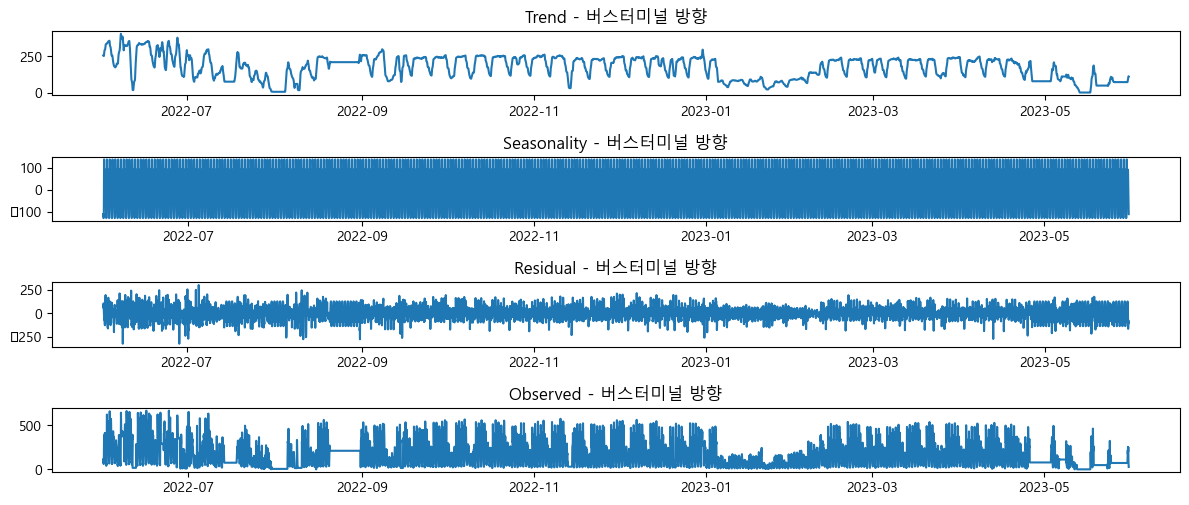

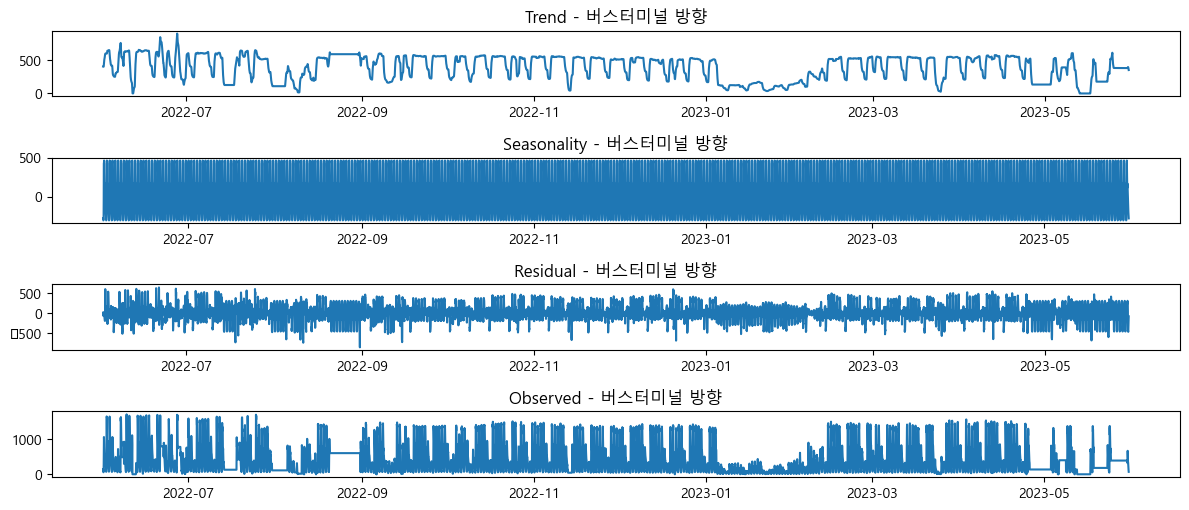

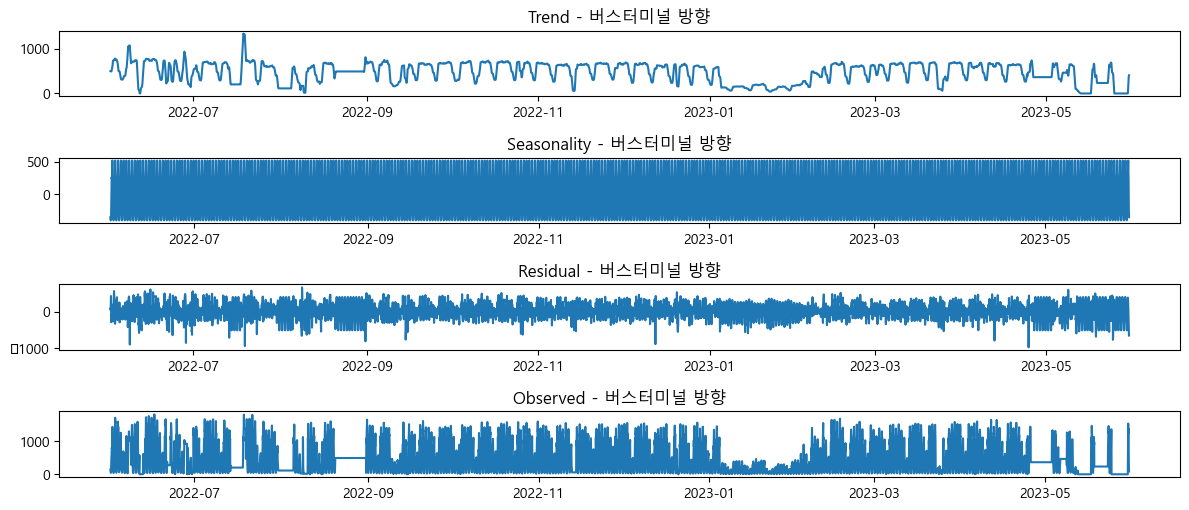

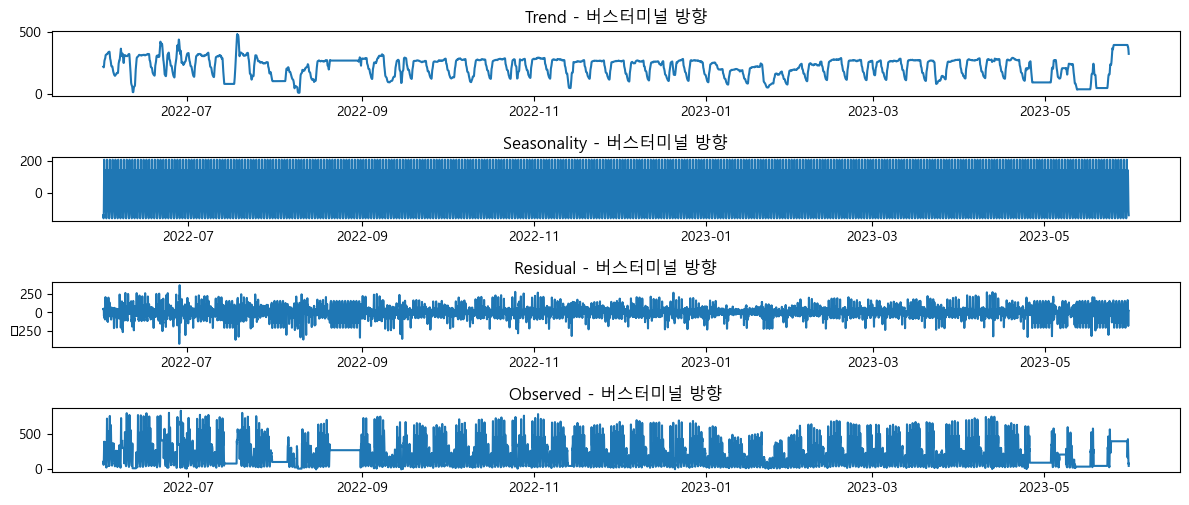

In [360]:
# 시계열 분석 결과 시각화
name = [decomposition_SN, decomposition_EW, decomposition_WE, decomposition_NS]

for i in range(4):
    plt.figure(figsize=(12, 20))
    plt.subplot(16, 1, 1 + 4*(i))
    plt.plot(name[i].trend)
    plt.title('Trend - 버스터미널 방향')

    plt.subplot(16, 1, 2 + 4*(i))
    plt.plot(name[i].seasonal)
    plt.title('Seasonality - 버스터미널 방향')

    plt.subplot(16, 1, 3 + 4*(i))
    plt.plot(name[i].resid)
    plt.title('Residual - 버스터미널 방향')

    plt.subplot(16, 1, 4 + 4*(i))
    plt.plot(name[i].observed)
    plt.title('Observed - 버스터미널 방향')

    plt.tight_layout()
    plt.show()

In [362]:
df_name = [df_SN, df_EW, df_WE, df_NS]

In [364]:
def adf_test(timeseries, pvalue = .05, regression_option = 'ct'):
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC', regression = regression_option)
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
    if dfoutput[1] < pvalue:
        print(f"정상시계열이 아니라는 귀무가설을 {pvalue*100}%의 유의수준으로 기각할 수 있으므로 해당 데이터는 정상성이 보장됩니다.")
    else:
        print(f"정상시계열이 아니라는 귀무가설을 {pvalue*100}%의 유의수준으로 기각할 수 없으므로 해당 데이터는 정상성을 보장하지 못합니다.")

adf_test(df_SN['교통량'])

Results of Dickey-Fuller Test:
Test Statistic                -1.005596e+01
p-value                        1.757090e-15
Lags Used                      3.600000e+01
Number of Observations Used    8.700000e+03
Critical Value (1%)           -3.959811e+00
Critical Value (5%)           -3.410995e+00
Critical Value (10%)          -3.127347e+00
dtype: float64
정상시계열이 아니라는 귀무가설을 5.0%의 유의수준으로 기각할 수 있으므로 해당 데이터는 정상성이 보장됩니다.


In [365]:
def kpss_test(timeseries, pvalue = .05, regression_option = 'ct'):
    print ('Results of KPSS Test:')
    kpsstest = kpss(timeseries, regression= regression_option)
    kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','Lags Used'])
    for key,value in kpsstest[3].items():
        kpss_output['Critical Value (%s)'%key] = value
    print (kpss_output)
    if kpss_output[1] < pvalue:
        print(f"정상시계열이 맞다는 귀무가설을 {pvalue*100}%의 유의수준으로 기각할 수 있으므로 해당 데이터는 정상성을 보장하지 못합니다.")
    else:
        print(f"정상시계열이 맞다는 귀무가설을 {pvalue*100}%의 유의수준으로 기각할 수 없으므로 해당 데이터는 정상성이 보장됩니다.")
        
kpss_test(df_SN['교통량'])

Results of KPSS Test:
Test Statistic            0.384917
p-value                   0.010000
Lags Used                43.000000
Critical Value (10%)      0.119000
Critical Value (5%)       0.146000
Critical Value (2.5%)     0.176000
Critical Value (1%)       0.216000
dtype: float64
정상시계열이 맞다는 귀무가설을 5.0%의 유의수준으로 기각할 수 있으므로 해당 데이터는 정상성을 보장하지 못합니다.
